<a href="https://colab.research.google.com/github/LizethArista/Manejo_de_datos/blob/main/5_Complejidad_algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complejidad Computacional

- **Complejidad temporal:** cuántas operaciones realiza un algoritmo en función del tamaño de la entrada `n`

- **Complejidad espacial:** cuánta memoria adicional necesita

- **Notación Big O:** describe el **peor caso** de crecimiento

In [14]:
# ============================================================
# Imports necesarios para toda la clase
# ============================================================
import time          # Para medir tiempos de ejecución
import matplotlib.pyplot as plt   # Para graficar
import numpy as np   # Para cálculos numéricos
import math          # Para funciones matemáticas

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## ¿Qué es la complejidad computacional?

Imagina que tienes que ordenar una lista de nombres. Si la lista tiene **10 nombres**, tardas segundos. Si tiene **1 millón**, puede tardar horas

La **complejidad computacional** nos dice **cómo crece el tiempo (o memoria)** a medida que la entrada `n` se hace más grande

No medimos en **segundos** (porque depende del computador), sino en **número de operaciones** en función de `n`

Se escribe como **O(f(n))** y describe el **comportamiento asintótico**

| Notación | Nombre | Ejemplo típico |
|----------|--------|----------------|
| O(1) | Constante | Acceder a un elemento de un array |
| O(log n) | Logarítmico | Búsqueda binaria |
| O(n) | Lineal | Recorrer una lista |
| O(n log n) | Line-logarítmico | Algoritmos de ordenamiento eficientes |
| O(n^2) | Cuadrático | Dos bucles anidados |
| O(2^n) | Exponencial | Fibonacci recursivo ingenuo |

In [15]:
# ============================================================
# O(1) — COMPLEJIDAD CONSTANTE
# ============================================================
# El tiempo NO depende del tamaño de la entrada
# Siempre tarda lo mismo, sin importar si la lista tiene 10 o 10 millones

def primer_elemento(lista):
    """
    Retorna el primer elemento de una lista.
    Complejidad: O(1) — solo accede a la posición 0
    """
    return lista[0]   # Una sola operación

lista_pequena = [10, 20, 30, 40, 50]
lista_grande = list(range(10000000))

print("Primer elemento (lista pequeña):", primer_elemento(lista_pequena))
print("Primer elemento (lista grande):  ", primer_elemento(lista_grande))

Primer elemento (lista pequeña): 10
Primer elemento (lista grande):   0


In [16]:
# ============================================================
# O(n) — COMPLEJIDAD LINEAL
# ============================================================
# El tiempo crece PROPORCIONALMENTE al tamaño de la entrada
# Si la lista tiene el doble de elementos, tarda el doble

def buscar_maximo(lista):
    """
    Encuentra el máximo de una lista recorriéndola una vez
    Complejidad: O(n) — recorre cada elemento exactamente una vez
    """
    maximo = lista[0]
    for numero in lista:          # n iteraciones
        if numero > maximo:       # 1 comparación por iteración
            maximo = numero
    return maximo


print("Máximo de [3, 1, 4, 1, 5, 9]:", buscar_maximo([3, 1, 4, 1, 5, 9]))

# Medición de tiempo
for n in [1000, 100000, 10000000]:
    lista = list(range(n))
    inicio = time.time()
    buscar_maximo(lista)
    fin = time.time()
    print(f"n = {n},  tiempo: {fin - inicio:.6f} segundos")

Máximo de [3, 1, 4, 1, 5, 9]: 9
n = 1000,  tiempo: 0.000034 segundos
n = 100000,  tiempo: 0.003257 segundos
n = 10000000,  tiempo: 0.344242 segundos


In [17]:
# ============================================================
# O(n^2) — COMPLEJIDAD CUADRÁTICA
# ============================================================
# El tiempo crece con el CUADRADO del tamaño de la entrada
# Típico de bucles anidados

def tiene_duplicados(lista):
    """
    Verifica si hay elementos repetidos comparando cada par
    Complejidad: O(n^2) — dos bucles anidados.

    MALA PRÁCTICA: hay formas O(n) de hacer esto con un set
    """
    n = len(lista)
    for i in range(n):                 # n iteraciones
        for j in range(i + 1, n):      # n-i iteraciones por cada i
            if lista[i] == lista[j]:
                return True
    return False

# Prueba
print("¿Duplicados en [1, 2, 3, 4]?", tiene_duplicados([1, 2, 3, 4]))
print("¿Duplicados en [1, 2, 3, 1]?", tiene_duplicados([1, 2, 3, 1]))

# Medición de tiempo
for n in [1000, 5000, 10000]:
    lista = list(range(n))
    inicio = time.time()
    tiene_duplicados(lista)
    fin = time.time()
    print(f"n = {n:}, tiempo: {fin - inicio:.6f} segundos")

¿Duplicados en [1, 2, 3, 4]? False
¿Duplicados en [1, 2, 3, 1]? True
n = 1000, tiempo: 0.027863 segundos
n = 5000, tiempo: 0.655445 segundos
n = 10000, tiempo: 2.585192 segundos


## ¿Por qué O(n²) es peligroso?

Si `n = 10`, haces ~100 operaciones
Si `n = 10,000`, haces ~100,000,000 operaciones  
Si `n = 1,000,000`, haces ~1,000,000,000,000 operaciones


In [18]:
 def tiene_duplicados_rapido(lista):
    """Versión O(n) usando un set."""
    vistos = set()
    for x in lista:
        if x in vistos:
            return True
        vistos.add(x)
    return False


# Prueba
print("¿Duplicados en [1, 2, 3, 4]?", tiene_duplicados_rapido([1, 2, 3, 4]))
print("¿Duplicados en [1, 2, 3, 1]?", tiene_duplicados_rapido([1, 2, 3, 1]))

# Medición de tiempo
for n in [1000, 5000, 10000]:
    lista = list(range(n))
    inicio = time.time()
    tiene_duplicados_rapido(lista)
    fin = time.time()
    print(f"n = {n:}, tiempo: {fin - inicio:.6f} segundos")

¿Duplicados en [1, 2, 3, 4]? False
¿Duplicados en [1, 2, 3, 1]? True
n = 1000, tiempo: 0.000065 segundos
n = 5000, tiempo: 0.000425 segundos
n = 10000, tiempo: 0.000562 segundos


In [19]:
# ============================================================
# O(log n) — COMPLEJIDAD LOGARÍTMICA
# ============================================================
# En cada paso reducimos el problema a la MITAD.
# Muy eficiente para datos ORDENADOS.

def busqueda_binaria(lista_ordenada, objetivo):
    """
    Busca 'objetivo' en una lista ordenada dividiendo a la mitad
    Complejidad: O(log n)

    Ejemplo: en una lista de 1 millón, solo 20 pasos aprox
    """
    izquierda = 0
    derecha = len(lista_ordenada) - 1

    while izquierda <= derecha:
        medio = (izquierda + derecha) // 2   # División a la mitad

        if lista_ordenada[medio] == objetivo:
            return medio                      # Encontrado
        elif lista_ordenada[medio] < objetivo:
            izquierda = medio + 1             # Buscar en la mitad derecha
        else:
            derecha = medio - 1               # Buscar en la mitad izquierda

    return -1   # No encontrado

# Prueba
lista = list(range(0, 1000000, 2))  # 500,000 números pares
print("Posición del 999,998:", busqueda_binaria(lista, 999_998))
print("Posición del 7 (no existe):", busqueda_binaria(lista, 7))

# Comparación: búsqueda lineal vs binaria
print("\n Comparación:")
print(f"Lista de 1 millón: lineal = hasta 1,000,000 pasos")
print(f"Lista de 1 millón: binaria = hasta log2(1,000,000) ≈ {math.log2(1000000):.1f} pasos")

Posición del 999,998: 499999
Posición del 7 (no existe): -1

 Comparación:
Lista de 1 millón: lineal = hasta 1,000,000 pasos
Lista de 1 millón: binaria = hasta log2(1,000,000) ≈ 19.9 pasos


In [29]:
# ============================================================
# O(n log n) — COMPLEJIDAD LINE-LOGARÍTMICA
# ============================================================
# Es el límite teórico para ordenar por comparaciones.
# Ejemplos: MergeSort, QuickSort (caso promedio), Timsort (Python)

def merge_sort(lista):
    """
    Ordena una lista usando el algoritmo Merge Sort.
    Complejidad: O(n log n) en TODOS los casos.
    """
    if len(lista) <= 1:
        return lista

    medio = len(lista) // 2
    izquierda = merge_sort(lista[:medio])   # O(log n) niveles
    derecha = merge_sort(lista[medio:])

    return _merge(izquierda, derecha)       # O(n) trabajo por nivel

def _merge(izq, der):
    """Fusiona dos listas ordenadas en una sola."""
    resultado = []
    i = j = 0
    while i < len(izq) and j < len(der):
        if izq[i] <= der[j]:
            resultado.append(izq[i])
            i += 1
        else:
            resultado.append(der[j])
            j += 1
    resultado.extend(izq[i:])
    resultado.extend(der[j:])
    return resultado

# Prueba
import random
lista_random = [random.randint(1, 1000) for _ in range(1000)]
lista_ordenada = merge_sort(lista_random)
print("¿Está ordenada?", lista_ordenada == sorted(lista_random))
print("Primeros 10:", lista_ordenada[:10])

¿Está ordenada? True
Primeros 10: [1, 2, 3, 3, 4, 4, 4, 5, 6, 6]


# Numero fiboacci
F(0) = 0

F(1) = 1

F(n) = F(n-1) + F(n-2)   para n ≥ 2

In [31]:
# ============================================================
# O(2ⁿ) — COMPLEJIDAD EXPONENCIAL
# ============================================================
# El tiempo se DUPLICA con cada elemento adicional
# ¡PELIGROSO! Solo sirve para n muy pequeños

def fibonacci_recursivo(n):
    """
    Calcula el n-ésimo número de Fibonacci de forma ingenua
    Complejidad: O(2^n) — hace DOS llamadas recursivas por paso
    """
    if n <= 1:
        return n
    return fibonacci_recursivo(n - 1) + fibonacci_recursivo(n - 2)

# Prueba con valores pequeños
print("Fibonacci(10):", fibonacci_recursivo(10))
print("Fibonacci(20):", fibonacci_recursivo(20))

# NO ejecutar fibonacci_recursivo(40) — tardaría minutos
print("\n  Fibonacci(35) tarda varios segundos...")
inicio = time.time()
fibonacci_recursivo(35)
print(f"Tiempo: {time.time() - inicio:.2f} segundos")

# Solución: programación dinámica O(n)
def fibonacci_dp(n):
    """Versión O(n) con memorización"""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

print("\n Fibonacci(1000) con DP:", fibonacci_dp(1000))

Fibonacci(10): 55
Fibonacci(20): 6765

  Fibonacci(35) tarda varios segundos...
Tiempo: 2.14 segundos

 Fibonacci(1000) con DP: 43466557686937456435688527675040625802564660517371780402481729089536555417949051890403879840079255169295922593080322634775209689623239873322471161642996440906533187938298969649928516003704476137795166849228875


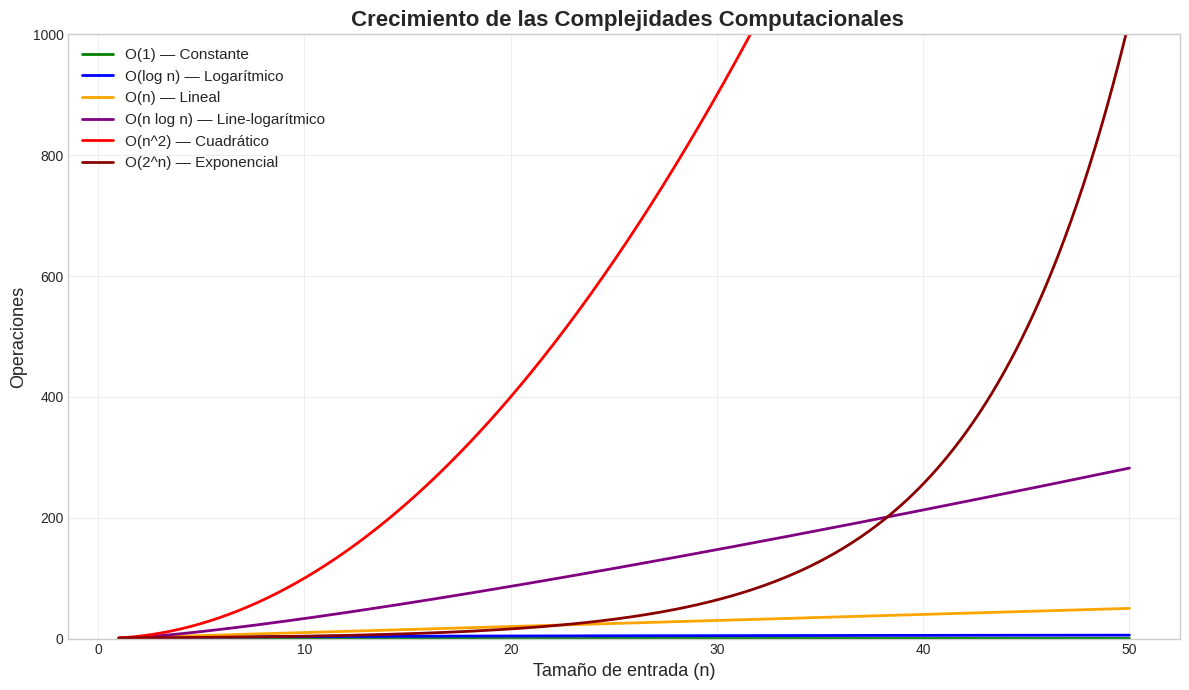


 Observa cómo O(2^n) y O(n^2) se disparan rápidamente


In [ ]:
# ============================================================
# VISUALIZACIÓN: crecimiento de las complejidades
# ============================================================

# Rango de valores de n
n = np.linspace(1, 50, 500)

# Funciones de crecimiento
O1 = np.ones_like(n)
O_log_n = np.log2(n)
O_n = n
O_n_log_n = n * np.log2(n)
O_n2 = n ** 2
O_2n = 2 ** (n / 5)   # Escalado para que quepa en el gráfico

# Gráfico
plt.figure(figsize=(12, 7))
plt.plot(n, O1, label='O(1) — Constante', linewidth=2, color='green')
plt.plot(n, O_log_n, label='O(log n) — Logarítmico', linewidth=2, color='blue')
plt.plot(n, O_n, label='O(n) — Lineal', linewidth=2, color='orange')
plt.plot(n, O_n_log_n, label='O(n log n) — Line-logarítmico', linewidth=2, color='purple')
plt.plot(n, O_n2, label='O(n^2) — Cuadrático', linewidth=2, color='red')
plt.plot(n, O_2n, label='O(2^n) — Exponencial', linewidth=2, color='darkred')

plt.title(' Crecimiento de las Complejidades Computacionales', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño de entrada (n)', fontsize=13)
plt.ylabel('Operaciones', fontsize=13)
plt.legend(fontsize=11, loc='upper left')
plt.ylim(0, 1000)   # Limitamos el eje Y para ver mejor
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Observa cómo O(2^n) y O(n^2) se disparan rápidamente")


 Midiendo tiempos reales:

     n |   O(n) seg |  O(n²) seg
-----------------------------------
   100 |   0.000007 |   0.000796
   500 |   0.000030 |   0.009789
  1000 |   0.000055 |   0.036797
  2000 |   0.000069 |   0.158327
  4000 |   0.000150 |   0.594210


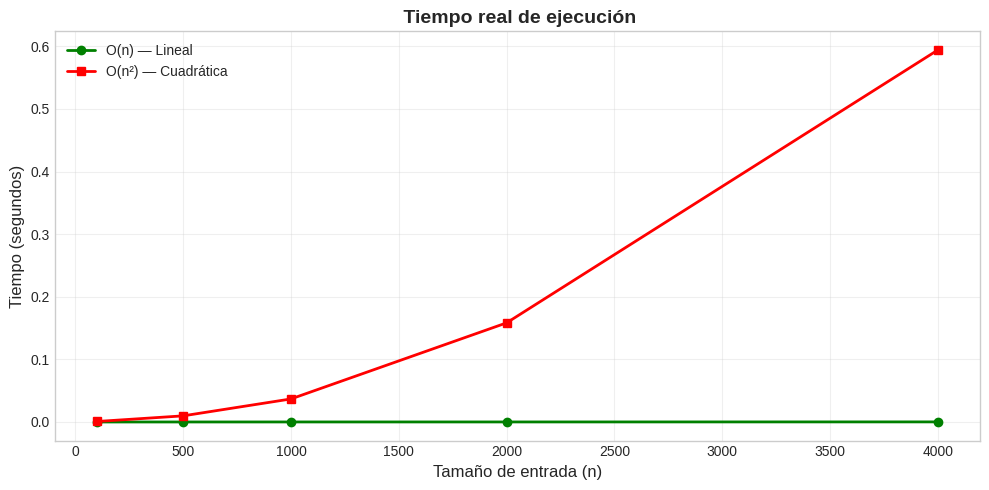

In [ ]:
# ============================================================
# MEDICIÓN REAL DE TIEMPOS DE EJECUCIÓN
# ============================================================

def medir_tiempo(funcion, lista, repeticiones=3):
    """Mide el tiempo promedio de ejecutar una función."""
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.time()
        funcion(lista)
        fin = time.time()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)

# Funciones a comparar
def suma_lineal(lista):
    """O(n)"""
    total = 0
    for x in lista:
        total += x
    return total

def suma_cuadratica(lista):
    """O(n²) — hace n² operaciones innecesarias"""
    total = 0
    for x in lista:
        for y in lista:
            total += 1
    return total

# Mediciones
tamanos = [100, 500, 1000, 2000, 4000]
tiempos_lineal = []
tiempos_cuadratica = []

print(" Midiendo tiempos reales:\n")
print(f"{'n':>6} | {'O(n) seg':>10} | {'O(n²) seg':>10}")
print("-" * 35)

for n in tamanos:
    lista = list(range(n))
    t_lin = medir_tiempo(suma_lineal, lista)
    t_cua = medir_tiempo(suma_cuadratica, lista)
    tiempos_lineal.append(t_lin)
    tiempos_cuadratica.append(t_cua)
    print(f"{n:>6} | {t_lin:>10.6f} | {t_cua:>10.6f}")

# Gráfico comparativo
plt.figure(figsize=(10, 5))
plt.plot(tamanos, tiempos_lineal, 'o-', label='O(n) — Lineal', color='green', linewidth=2)
plt.plot(tamanos, tiempos_cuadratica, 's-', label='O(n^2) — Cuadrática', color='red', linewidth=2)
plt.title(' Tiempo real de ejecución', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de entrada (n)', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ejercicio 1
Determina la complejidad Big O de cada función:

```python
def funcion_a(n):
    suma = 0
    for i in range(n):
        suma += i
    return suma

def funcion_b(n):
    for i in range(n):
        for j in range(n):
            print(i, j)

def funcion_c(n):
    i = 1
    while i < n:
        i *= 2

# Ejercicio 2

La siguiente función es O(n²). Reescríbela para que sea O(n):



In [ ]:
def contar_pares_unicos(lista):
    """Cuenta cuántos pares (a, b) con a ≠ b suman 10."""
    contador = 0
    for i in range(len(lista)):
        for j in range(i + 1, len(lista)):
            if lista[i] + lista[j] == 10:
                contador += 1
    return contador

# Ejercicio 3

Si un algoritmo O(n²) tarda 1 segundo con n = 1000,
¿cuánto tardará con n = 10,000?

## Recomendaciones....

1. **Evitar bucles anidados** sobre la misma entrada, suelen ser O(n²)

2. **Usa sets y diccionarios** para búsquedas,son O(1) en promedio

3. **Si los datos están ordenados**, usa búsqueda binaria, para que sea O(log n)

4. **Recursión** casi siempre es exponencial, usa memorización

